# Sieci konwolucyjne część 2.

**Uwaga:** Poniższy notebook jest stworzony z myślą o uruchamianiu go w [Colaboratory](https://colab.research.google.com/) (link do przeglądania repozytoriów w colabie: [link](https://colab.research.google.com/github/)), oznacza to, że przygotowane zadania zakładają uczenie modelu z użyciem GPU. Na zajęciach zostanie krótko omówione używanie Colaboratory. Na własną odpowiedzialność można używać własnego komputera do rozwiązania pracy domowej.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision.transforms import (RandomVerticalFlip,
                                    ToTensor)
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

### CIFAR10
[CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) to dataset zawierający 60 tysięcy kolorowych obrazków rozmiaru 32 $\times$ 32 pikseli należących do 10 różnych klas. Poniżej przykładowe wizualizacje.

Files already downloaded and verified
CIFAR10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


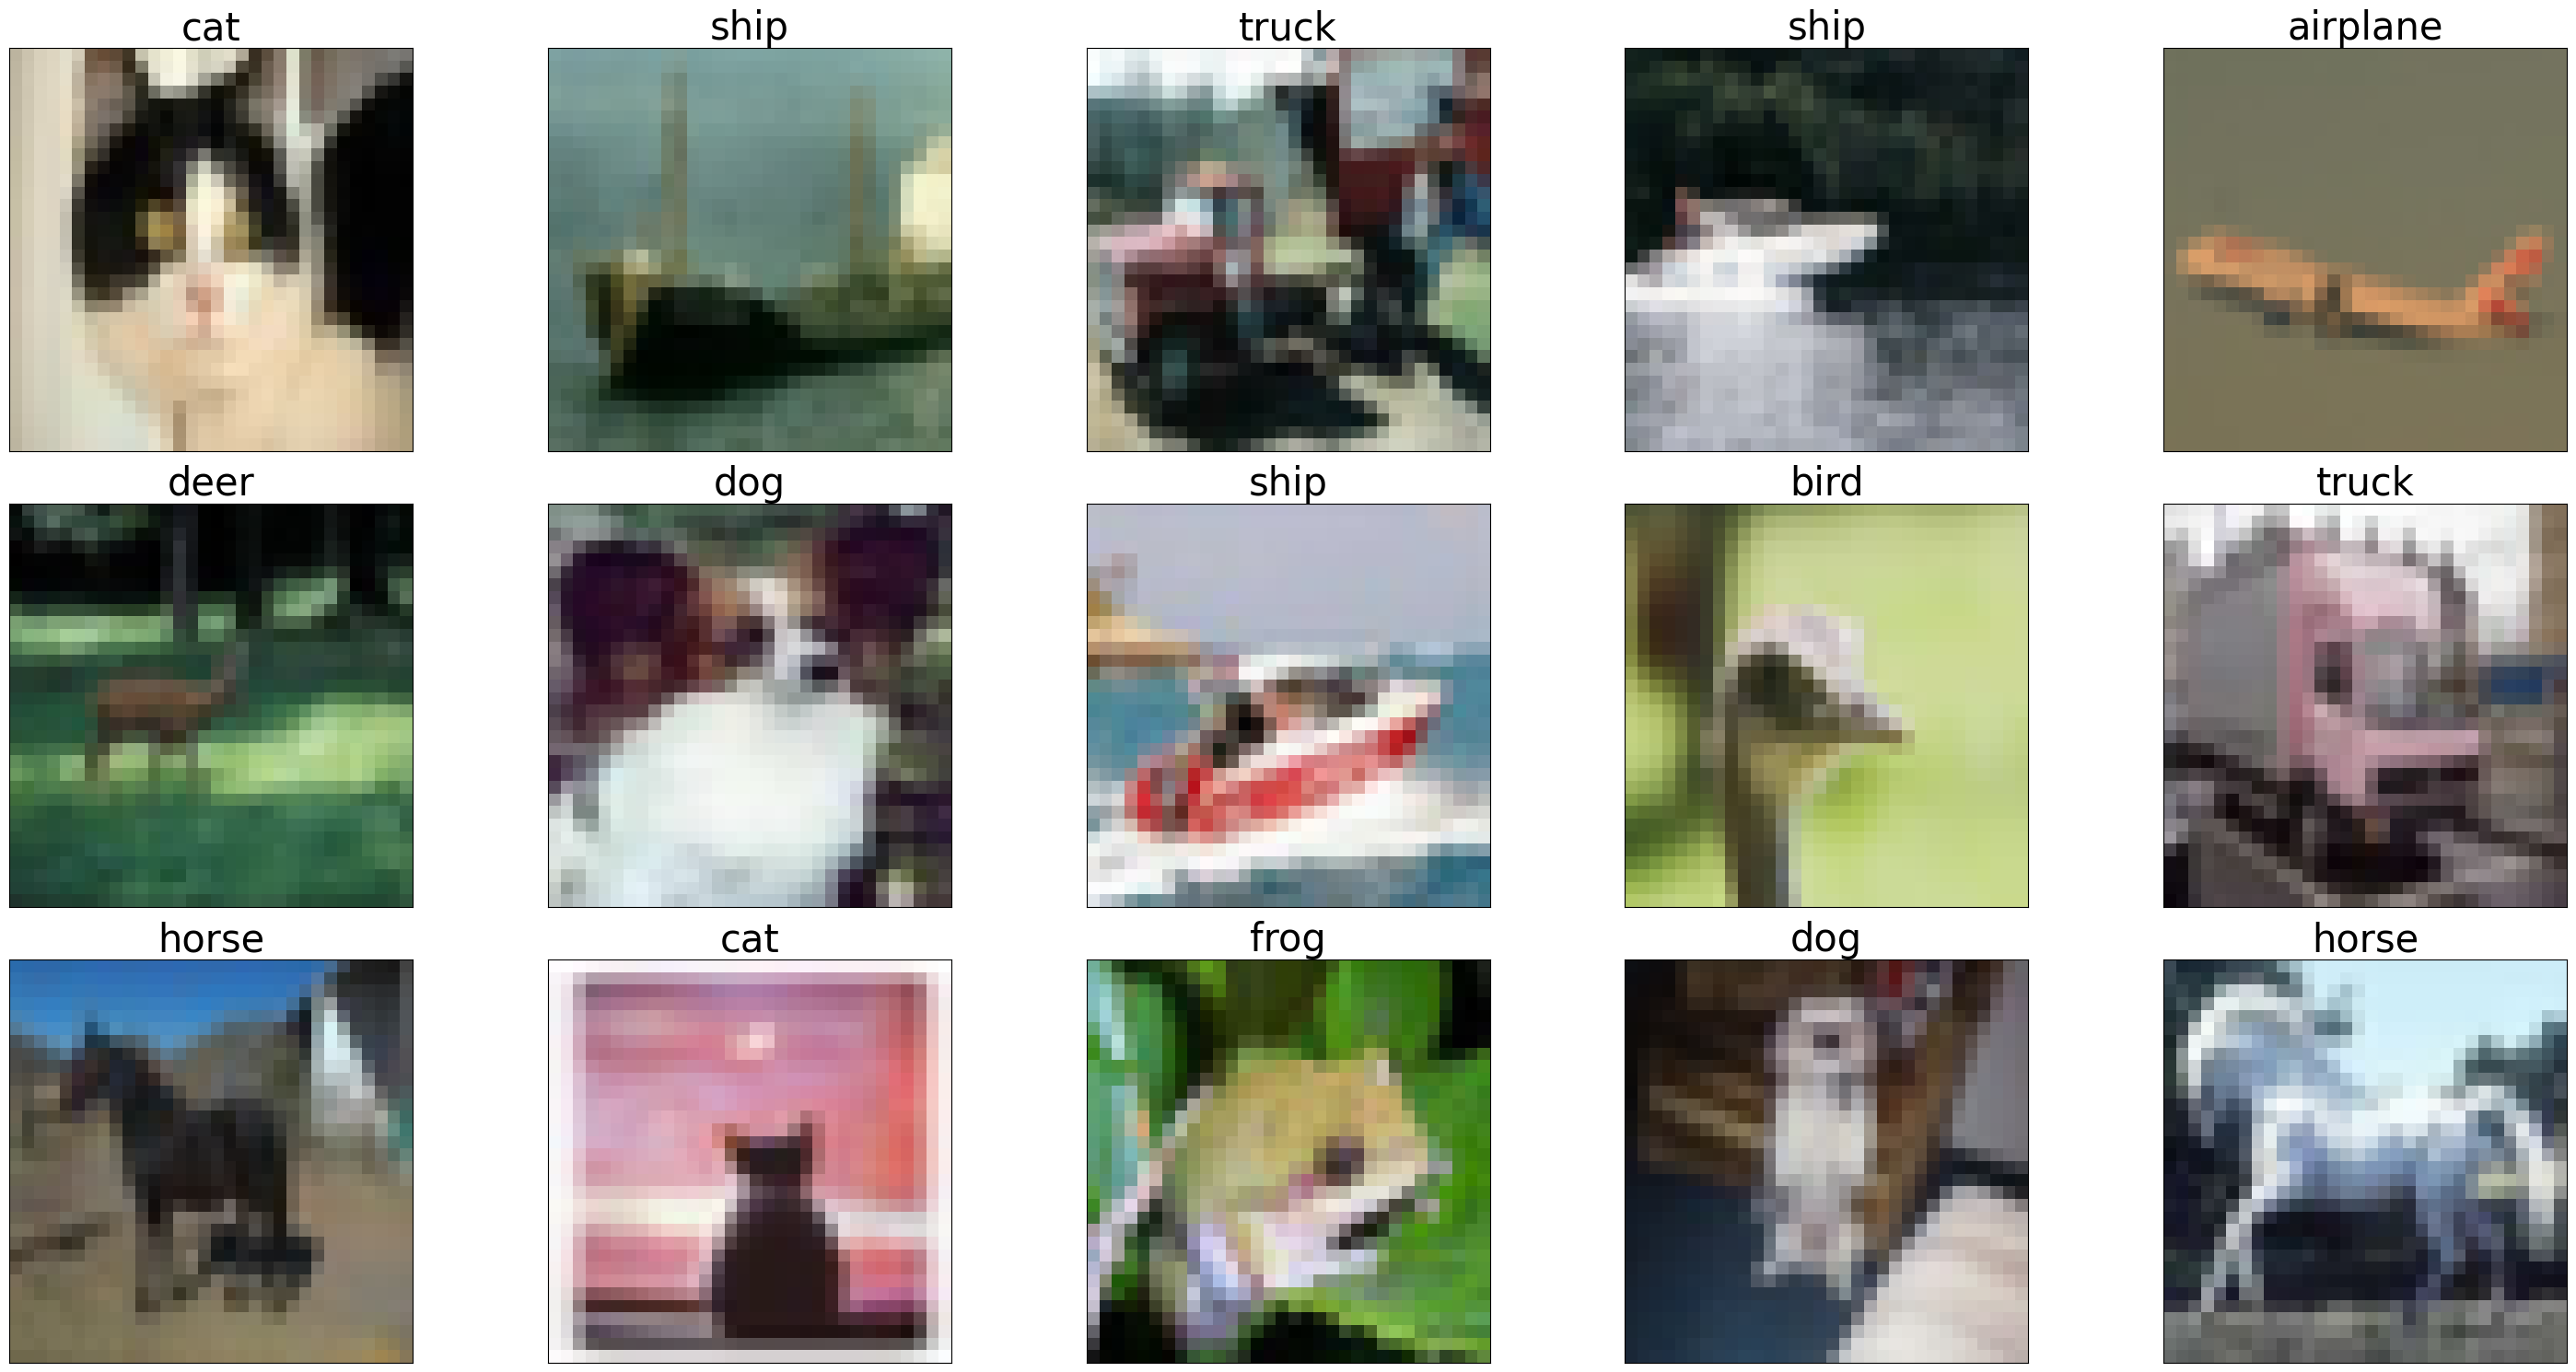

In [14]:
dataset = CIFAR10(root=".", train=True, transform=ToTensor(), download=True)
loader = DataLoader(dataset, batch_size=15, shuffle=True)

# get a single batch
for x, y in loader:
    break

# prepare visualisations
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(30, 15))
for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ind = 5 * i + j
        ax.imshow(np.transpose(x[ind], (1, 2, 0)))
        ax.set_title(f"{dataset.classes[y[ind]]}", fontdict={"size": 30})
        ax.set_xticks([])
        ax.set_yticks([])

fig.tight_layout()

print(f"CIFAR10 classes: {dataset.classes}")

### Zadanie 1. Sieć Konwolucyjna na CIFAR10 (4 pkt.)

Zadaniem jest zaimplementowanie "od zera" sieci konwolucyjnej do klasyfikacji wieloklasowej na zbiorze CIFAR10. Należy zaimplementować zarówno model jak i pętle uczenia oraz ewaluacji. Twój kod powinien raportować *loss* w trakcie trenowania, testowania oraz *accuracy* na zbiorze testowym (opcjonalnie również na treningowym). Na koniec *accuracy* powinno osiągnąć wynik powyżej 75% na zbiorze testowym. Można korzystać z dowolnych mechanizmów dostępnych w PyTorchu.

Porady do zadania:

* Zwiększenie treningowego *batch size* może przyspieszyć uczenie, ale należy pamiętać, że, tak jak każdy hiperparametr, *batch_size* ma wpływ na proces uczenia.
* Przy dobieraniu architektury bądź hiperparametrów nie testować dłużej niż kilka epok (około 5), tak aby mieć szybki feedback. Dopiero po dobraniu powyższych rzeczy puścić dłuższe uczenie. Warto przy okazji wizualizować krzywe uczenia (funkcji kosztu) aby zwrócić uwagę na to kiedy koszt zaczyna się "wypłaszczać" i czy model przypadkowo nie overfituje (patrząc na wartości kosztu na zbiorze testowym)
* Dodatkowe (nadobowiązkowe) rzeczy do poprawienia wyniku: LR Schedule, Early Stopping.

In [15]:
# tutaj zdefiniuj swój model, nie zapomnij o dziedziczeniu z torch.nn.Module
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

model = MyCNN()

In [16]:
# tutaj uzupełnij ładowanie danych treningowych i testowych
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = CIFAR10(root='.', 
                        train=True,
                        download=True,
                        transform=transform)

test_dataset = CIFAR10(root='.', 
                       train=False,
                       download=True,
                       transform=transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

Files already downloaded and verified
Files already downloaded and verified


In [17]:
# tutaj zaimplementuj pętle uczenia ze wszystkimi potrzebnymi hiperparametrami
criterion = nn.CrossEntropyLoss()

# Definicja optymalizatora
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Liczba epok
num_epochs = 10

# Pętla uczenia
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # Przygotowanie danych
        inputs, labels = data

        # Zerowanie gradientów
        optimizer.zero_grad()

        # Przebieg w przód
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Propagacja wsteczna i aktualizacja wag
        loss.backward()
        optimizer.step()

        # Sumowanie straty
        running_loss += loss.item()
        if i % 200 == 199:    # Co 200 mini-batchy
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 200))
            running_loss = 0.0

[1,   200] loss: 2.293
[1,   400] loss: 2.225
[1,   600] loss: 2.082
[2,   200] loss: 1.868
[2,   400] loss: 1.801
[2,   600] loss: 1.754
[3,   200] loss: 1.655
[3,   400] loss: 1.611
[3,   600] loss: 1.584
[4,   200] loss: 1.496
[4,   400] loss: 1.469
[4,   600] loss: 1.426
[5,   200] loss: 1.372
[5,   400] loss: 1.385
[5,   600] loss: 1.340
[6,   200] loss: 1.321
[6,   400] loss: 1.277
[6,   600] loss: 1.272
[7,   200] loss: 1.238
[7,   400] loss: 1.234
[7,   600] loss: 1.232
[8,   200] loss: 1.196
[8,   400] loss: 1.179
[8,   600] loss: 1.163
[9,   200] loss: 1.128
[9,   400] loss: 1.122
[9,   600] loss: 1.138
[10,   200] loss: 1.096
[10,   400] loss: 1.091
[10,   600] loss: 1.064


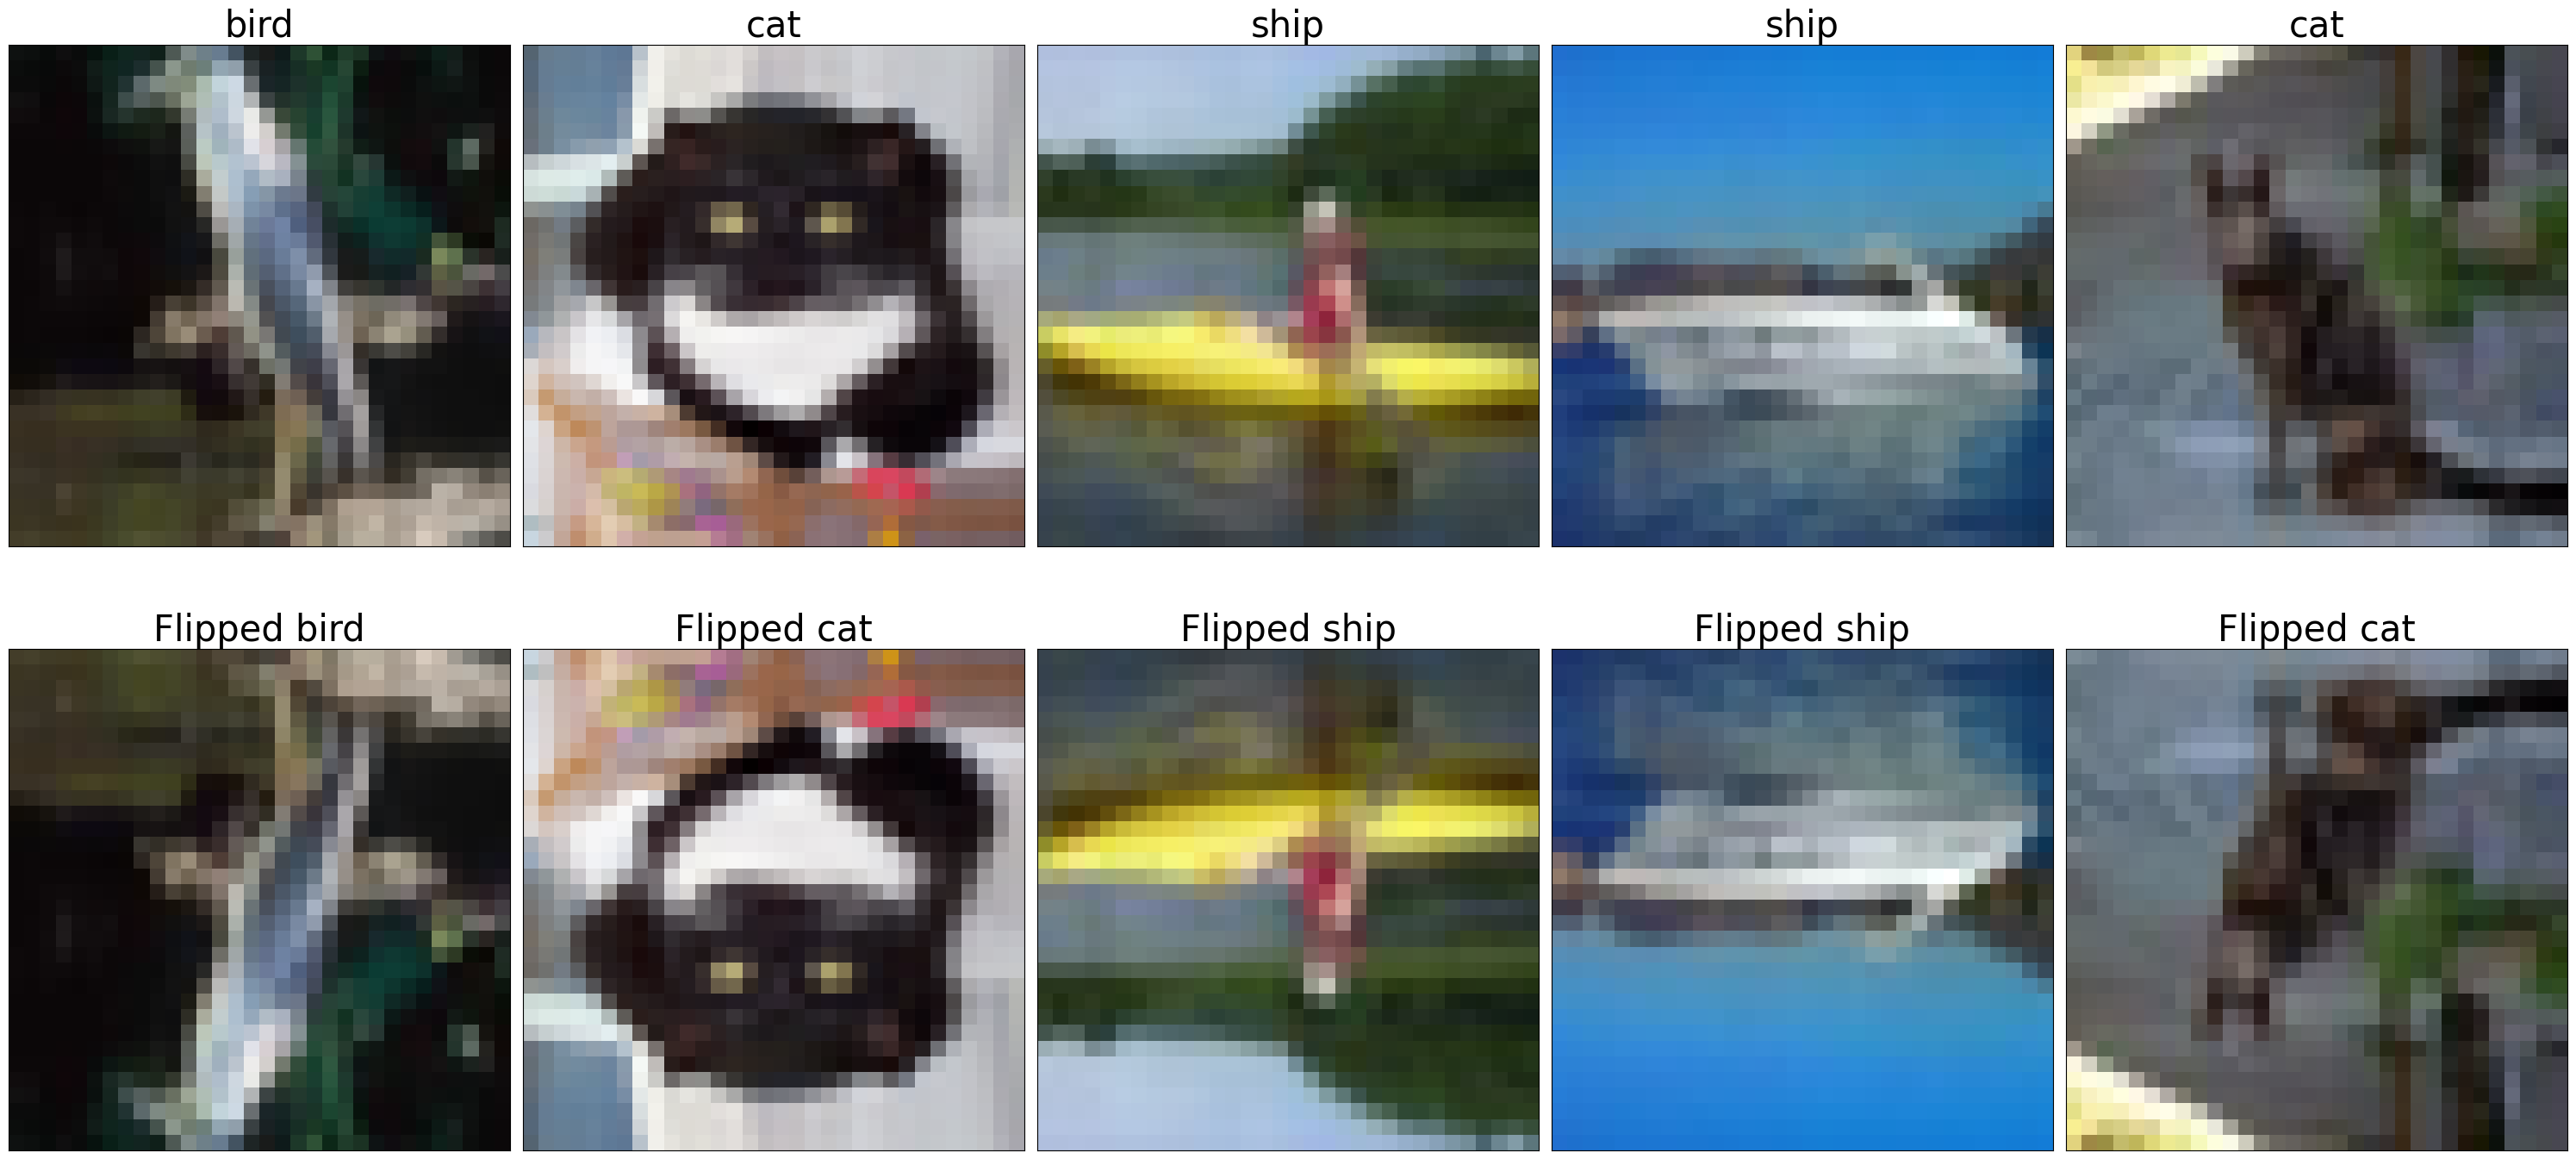

In [18]:
# load test set
dataset = CIFAR10(root=".", train=True, transform=ToTensor())
loader = DataLoader(dataset, batch_size=15, shuffle=True)

# prepare a random flip
flip = RandomVerticalFlip(p=1)

# load some data
for x, y in loader:
    break


# visualise the flipping
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30, 15))

for img, label, ax in zip(x, y, axes[0]):
    ax.imshow(np.transpose(img, (1, 2, 0)))
    ax.set_title(f"{dataset.classes[label]}", fontdict={"size": 30})
    ax.set_xticks([])
    ax.set_yticks([])

for img, label, ax in zip(x, y, axes[1]):
    ax.imshow(np.transpose(flip(img), (1, 2, 0)))
    ax.set_title(f"Flipped {dataset.classes[label]}", fontdict={"size": 30})
    ax.set_xticks([])
    ax.set_yticks([])


fig.tight_layout()

### Zadanie 2. Augmentacja danych (1 pkt.)

Używając funkcjonalności dostępnych w [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) dodaj augmentacje danych do datasetu treningowego, zobacz o ile poprawia to wynik twojego modelu z poprzedniego zadania. W razie wątpliwości najlepiej przeszukać internet w poszukiwaniu typowych augmentacji dla CIFAR10.

In [21]:
# tutaj dodaj wybrane augumentcje danych treningowych i załaduj testowe
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = CIFAR10(root='.', 
                        train=True,
                        download=True,
                        transform=train_transform)

test_dataset = CIFAR10(root='.', 
                       train=False,
                       download=True,
                       transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=5000, shuffle=False, num_workers=4)

Files already downloaded and verified
Files already downloaded and verified


In [22]:
criterion = nn.CrossEntropyLoss()

# Definicja optymalizatora
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Liczba epok
num_epochs = 10

# Pętla uczenia
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # Przygotowanie danych
        inputs, labels = data

        # Zerowanie gradientów
        optimizer.zero_grad()

        # Przebieg w przód
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Propagacja wsteczna i aktualizacja wag
        loss.backward()
        optimizer.step()

        # Sumowanie straty
        running_loss += loss.item()
        if i % 200 == 199:    # Co 200 mini-batchy
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 200))
            running_loss = 0.0

[1,   200] loss: 1.449
[1,   400] loss: 1.363
[1,   600] loss: 1.345
[2,   200] loss: 1.294
[2,   400] loss: 1.290
[2,   600] loss: 1.289
[3,   200] loss: 1.258
[3,   400] loss: 1.246
[3,   600] loss: 1.261
[4,   200] loss: 1.224
[4,   400] loss: 1.230
[4,   600] loss: 1.210
[5,   200] loss: 1.192
[5,   400] loss: 1.184
[5,   600] loss: 1.173
[6,   200] loss: 1.157
[6,   400] loss: 1.156
[6,   600] loss: 1.165
[7,   200] loss: 1.145
[7,   400] loss: 1.152
[7,   600] loss: 1.127
[8,   200] loss: 1.136
[8,   400] loss: 1.116
[8,   600] loss: 1.125
[9,   200] loss: 1.104
[9,   400] loss: 1.098
[9,   600] loss: 1.103
[10,   200] loss: 1.079
[10,   400] loss: 1.081
[10,   600] loss: 1.091


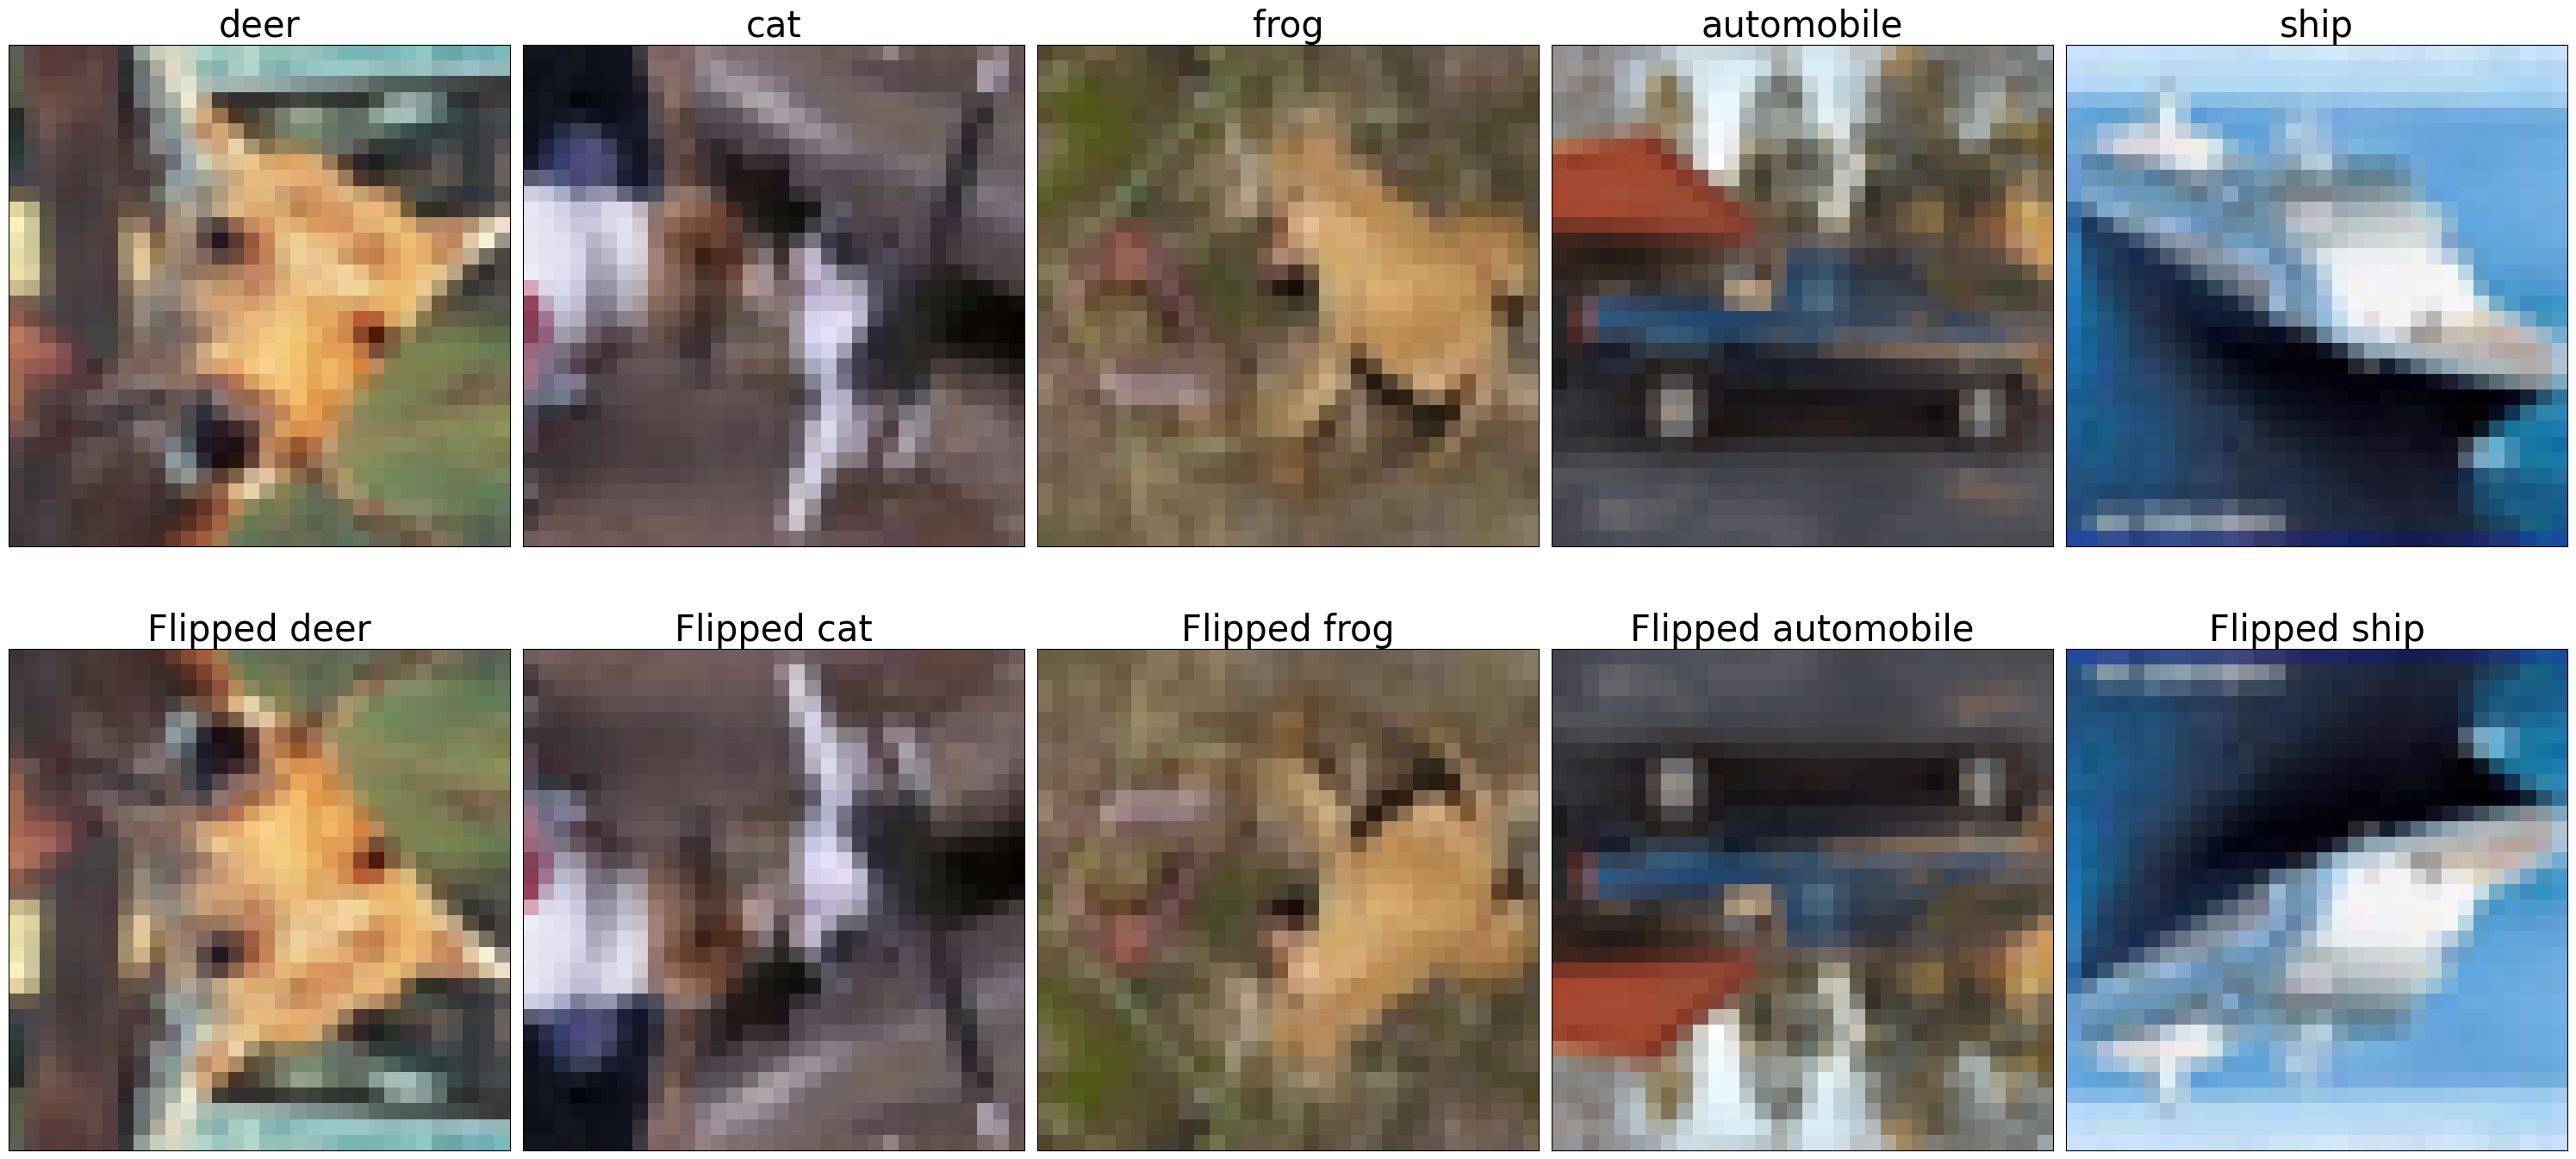

In [23]:
dataset = CIFAR10(root=".", train=True, transform=ToTensor())
loader = DataLoader(dataset, batch_size=15, shuffle=True)

# prepare a random flip
flip = RandomVerticalFlip(p=1)

# load some data
for x, y in loader:
    break


# visualise the flipping
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30, 15))

for img, label, ax in zip(x, y, axes[0]):
    ax.imshow(np.transpose(img, (1, 2, 0)))
    ax.set_title(f"{dataset.classes[label]}", fontdict={"size": 30})
    ax.set_xticks([])
    ax.set_yticks([])

for img, label, ax in zip(x, y, axes[1]):
    ax.imshow(np.transpose(flip(img), (1, 2, 0)))
    ax.set_title(f"Flipped {dataset.classes[label]}", fontdict={"size": 30})
    ax.set_xticks([])
    ax.set_yticks([])


fig.tight_layout()